# STANDARD: buybacks, branch demand and re-entry


**Pinned observation: 2026-09-16T01:47:19+00:00; Robinhood chain 4663, block 64126372.**
STANDARD `0x88ad8DdF1E3898412146a534538d418c6F8A9062`.
This supplements earlier research; it does not turn an earlier forecast into a successful prediction.

## Decision from cash

The observed regime favors **waiting for evidence of renewed buying** over automatically buying back after a fall. A rebound is quite possible: most recent selling addresses have emptied, and a relatively small number of large buyers can move this pool. But neither new branches nor the existing buyback reserve guarantees enough buying for a sustained recovery. There is no statistically defensible probability of recovery, or validated optimal re-entry time, from this short launch history.

The useful result is a set of capital requirements and observable decision rules. Since the wallet tokens have already been sold, the previous sale price is not an input to whether the next purchase has positive expected value. Existing Charter ownership, if any, is a separate decision.



In [1]:
from pathlib import Path
import json, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from liquidity import ConcentratedPool
from reentry_model import price_buy_cost
ROOT = Path.cwd()
OUT = ROOT / 'reentry-results'
m = json.loads((OUT/'summary.json').read_text())
profile = json.loads((ROOT/'reentry-evidence/liquidity.json').read_text())
pool = ConcentratedPool(profile)
pd.Series({k:v for k,v in m.items() if k!='withdrawals'})

snapshot_utc                                                             2026-09-16T01:47:19+00:00
block                                                                                     64126372
block_hash                                       0xd5045e1fee4176fd4c236b7db7feea5ec8d93d5aae0c...
price_ETH                                                                                 0.000107
actual_pool_ETH                                                                        2450.614637
active_virtual_ETH                                                                     3971.556822
protocol_buyback_depth_ETH                                                             3296.377858
live_charters                                                                                  999
owners                                                                                         941
branches                                                                                      1151
branches_r

## Fresh observations
All dates below are UTC. Buy/sell windows use interpolated block times; their exact underlying transaction IDs remain available. Cash is observed capacity, not a committed bid.

In [2]:
display(pd.read_csv(OUT/'participants/windows.csv'))
display(pd.read_csv(OUT/'capital-by-cohort.csv'))
display(pd.read_csv(OUT/'funding/followup-license-funding.csv').sum(numeric_only=True))

,window_hours,from_utc_approx,to_utc,side,attributed_pool_eth,all_pool_eth,attribution_fraction,attributed_tokens,addresses,tx_count,new_to_canonical_pool_buy_eth,charter_owner_pool_eth
0,0.333333,2026-09-16T01:27:19+00:00,2026-09-16T01:47:19+00:00,buy,1.912530,1.914547,0.998946,1.703334e+04,8,11,0.133510,1.455300
1,0.333333,2026-09-16T01:27:19+00:00,2026-09-16T01:47:19+00:00,sell,121.854037,141.743314,0.859681,1.106758e+06,79,99,0.000000,0.000000
2,2.000000,2026-09-15T23:47:19+00:00,2026-09-16T01:47:19+00:00,buy,306.018388,311.883221,0.981195,2.677912e+06,150,281,37.559554,107.088717
3,2.000000,2026-09-15T23:47:19+00:00,2026-09-16T01:47:19+00:00,sell,624.312769,644.486475,0.968698,5.469326e+06,245,316,0.000000,56.119849
4,6.000000,2026-09-15T19:47:19+00:00,2026-09-16T01:47:19+00:00,buy,568.374634,575.227035,0.988087,4.819206e+06,320,584,178.385629,146.232360
5,6.000000,2026-09-15T19:47:19+00:00,2026-09-16T01:47:19+00:00,sell,887.858255,909.440302,0.976269,7.662233e+06,447,608,0.000000,86.598026
6,12.000000,2026-09-15T13:47:19+00:00,2026-09-16T01:47:19+00:00,buy,1284.353456,1464.909742,0.876746,1.018091e+07,874,1646,482.552666,225.411630
7,12.000000,2026-09-15T13:47:19+00:00,2026-09-16T01:47:19+00:00,sell,2014.031949,2085.538763,0.965713,1.616369e+07,855,1544,0.000000,354.366014
8,24.000000,2026-09-15T01:47:19+00:00,2026-09-16T01:47:19+00:00,buy,8221.615306,8500.484189,0.967194,5.563829e+07,4278,12453,5427.856754,939.478905
9,24.000000,2026-09-15T01:47:19+00:00,2026-09-16T01:47:19+00:00,sell,8486.083123,8637.721574,0.982445,5.908918e+07,2751,11928,0.000000,1532.244543


,cohort,addresses,tokens,native_ETH,WETH,USDG,cash_observations
0,charter_operator,941,9.712404e+06,2595.166657,48.164942,1.580787e+06,941
1,inactive_or_unattributed,15431,4.569698e+07,2740.920121,151.398954,8.178013e+06,6798
2,net_buyer,222,7.401054e+06,688.770326,1.983996,6.248422e+05,222
3,net_seller,364,1.956920e+06,708.168240,7.058416,2.350260e+05,364
4,two_way_trader,61,2.654927e+05,120.611590,15.332688,7.570863e+04,61


charter_id                  2.848400e+04
cost_tokens                 1.231229e+06
prior_bank_balance          3.059408e+05
new_issuance                3.800686e+02
prefunded_wallet_tokens     8.068019e+05
new_canonical_tokens        9.940409e+04
new_other_custody_tokens    1.870205e+04
dtype: float64

## Buybacks and treasury
The owner counterfactual call succeeds; an ordinary caller fails NotExecutor. No past buybacks. These cases assume successful hourly execution, unchanged parameters, no replenishment and no opposing sellers. The hook balance can route to expansion or contraction at epoch settlement; it is not added to current buybacks.

In [3]:
display(pd.read_csv(OUT/'buyback-cases.csv'))
display(pd.Series(json.loads((OUT/'fee-reconciliation.json').read_text())))
display(pd.read_csv(OUT/'isolated-support-cases.csv'))
checks=json.loads((ROOT/'reentry-evidence/buyback-execution.json').read_text())
[(c['label'],c.get('decoded'),c['result']) for c in checks['checks']]

,hours,elapsed_days,through_utc,buy_tax_exemption_assumed,ETH_spent,vault_remaining,price_return
0,1,0.041667,2026-09-16T02:47:19+00:00,False,6.592756,105.126238,0.003222
1,1,0.041667,2026-09-16T02:47:19+00:00,True,6.592756,105.126238,0.003288
2,6,0.250000,2026-09-16T07:47:19+00:00,False,39.716061,72.002933,0.019488
3,6,0.250000,2026-09-16T07:47:19+00:00,True,39.719324,71.999670,0.019889
4,24,1.000000,2026-09-17T01:47:19+00:00,False,100.821081,10.897913,0.051092
5,24,1.000000,2026-09-17T01:47:19+00:00,True,100.821844,10.897150,0.052291
6,48,2.000000,2026-09-18T01:47:19+00:00,False,110.849706,0.869288,0.056941
7,48,2.000000,2026-09-18T01:47:19+00:00,True,110.849767,0.869227,0.058262


trading_tax_wei                                          2343038050967732609083
lp_eth_tax_wei                                              1204545462555541013
forwarded_wei                                                                 0
observed_balance_wei                                     2344242596430288150096
unexplained_difference_wei                                                    0
event_counts                  {'EpochWindowOpened': 1, 'TaxCollected': 50433...
dtype: object

,case,buy_wallet_ETH,no_seller_price_return
0,whole_current_buyback_balance_eventually,111.718994,0.057448
1,current_POL_balance_half_swap_only,167.578491,0.090326
2,all_remaining_licenses_fresh_bought_now,115.281553,0.059531


[('synthetic_public_caller',
  {'abiItem': {'type': 'error', 'name': 'NotExecutor', 'inputs': []},
   'errorName': 'NotExecutor'},
  {'jsonrpc': '2.0',
   'id': 2,
   'error': {'code': 3,
    'message': 'execution reverted',
    'data': '0xc32d1d76'}}),
 ('owner_counterfactual', None, {'jsonrpc': '2.0', 'id': 3, 'result': '0x'})]

## Branch allocation and waiting
Zero fresh buying is constructively feasible, not a prediction that every owner will participate. Internal ledgers and owner inventories are consumed once; daily per-Charter limits include earlier purchases. Future waiting cases assume licenses remain available.

In [4]:
display(pd.read_csv(OUT/'remaining-license-allocation.csv'))
display(pd.read_csv(OUT/'license-waiting.csv'))
display(pd.read_csv(OUT/'branch-payback.csv'))

,charter_id,owner,ledger_used,wallet_used,new_tokens_needed
0,92,0xb993494cf9f7d5a941349f1c7df2f3aa2fc877bd,21134.303089,0.000000,0.0
1,95,0x338188207e6256f0179b110d7f7bbce5a838f8ad,21134.303089,0.000000,0.0
2,277,0xc091c59489accde50de0ccdf1eddf6c5e5257678,21134.303089,0.000000,0.0
3,456,0xa4a5cc8c29353f333d031f7df7a717ef86caa7de,21134.303089,0.000000,0.0
4,456,0xa4a5cc8c29353f333d031f7df7a717ef86caa7de,21134.303089,0.000000,0.0
5,549,0xd4bb7351a9b0d1b236e7523da7a972db4a100f08,21134.303089,0.000000,0.0
6,589,0xcfb7698154899ae6c5913989f4833d4912b45fb6,21134.303089,0.000000,0.0
7,589,0xcfb7698154899ae6c5913989f4833d4912b45fb6,21134.303089,0.000000,0.0
8,589,0xcfb7698154899ae6c5913989f4833d4912b45fb6,21134.303089,0.000000,0.0
9,664,0x26d7b4fe67f4601643304b5023b3caf3a72e8504,21134.303089,0.000000,0.0


,elapsed_days,timestamp_utc,hours_wait,license_price,foregone_issuance_one_branch,all_remaining_licenses_tokens,all_fresh_ETH_at_snapshot_curve,feasible_fresh_tokens,fully_internal_licenses
0,0.000000,2026-09-16T01:47:19+00:00,0,21134.303089,0.000000,1.014447e+06,115.281553,0.0,20
1,0.083333,2026-09-16T03:47:19+00:00,2,15317.321411,50.680568,7.352314e+05,82.884524,0.0,22
2,0.166667,2026-09-16T05:47:19+00:00,4,11204.094220,101.361135,5.377965e+05,60.299618,0.0,42
3,0.333333,2026-09-16T09:47:19+00:00,8,6238.989785,202.722270,2.994715e+05,33.360166,0.0,48
4,0.500000,2026-09-16T13:47:19+00:00,12,3756.437568,304.083406,1.803090e+05,20.020960,0.0,48


,new_branches_per_day,gross_token_payback_days,payback_utc,branch_cap,assumption
0,0,34.781025,2026-10-20T20:31:59.517847061+00:00,9990,"Constant issuance and token price; no fees, no..."
1,50,81.213446,2026-12-06T06:54:40.719286919+00:00,9990,"Constant issuance and token price; no fees, no..."
2,100,174.204202,2027-03-09T06:41:22.087826014+00:00,9990,"Constant issuance and token price; no fees, no..."


## Recovery requirements
These ETH budgets include modeled buy tax and LP fee. Sale-first ordering is explicit. The grid uses the archived full initialized-tick curve and fixed locked liquidity.

,sold_tokens_first,target_return,target_price_ETH,fresh_wallet_ETH
0,0.0,0.050000,0.000113,98.946137
1,0.0,0.100000,0.000118,183.854754
2,0.0,0.250000,0.000134,428.218989
3,0.0,0.500000,0.000161,795.348022
4,0.0,0.790783,0.000192,1187.141108
5,1000000.0,0.050000,0.000113,205.486573
6,1000000.0,0.100000,0.000118,290.395190
7,1000000.0,0.250000,0.000134,534.759426
8,1000000.0,0.500000,0.000161,901.888458
9,1000000.0,0.790783,0.000192,1293.681545


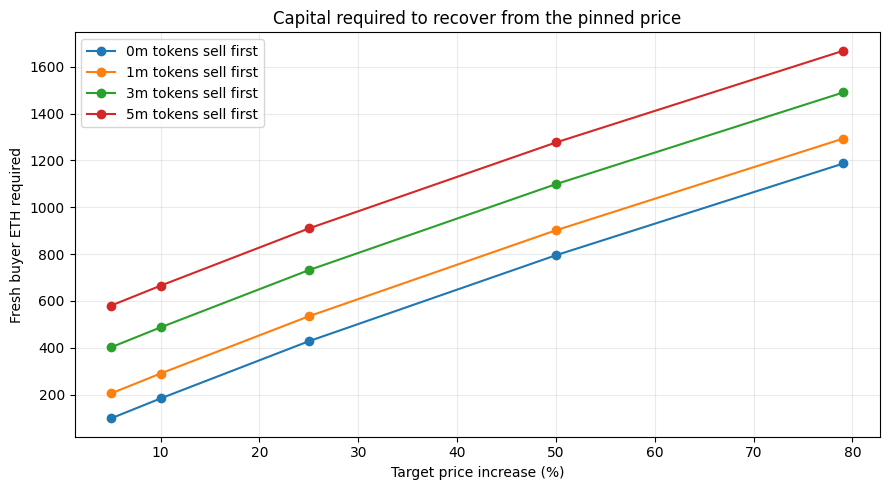

In [5]:
h=pd.read_csv(OUT/'price-hurdles.csv')
display(h)
fig,ax=plt.subplots(figsize=(9,5))
for sold,g in h.groupby('sold_tokens_first'):
    ax.plot(g.target_return*100,g.fresh_wallet_ETH,marker='o',label=f'{sold/1e6:g}m tokens sell first')
ax.set(xlabel='Target price increase (%)',ylabel='Fresh buyer ETH required',title='Capital required to recover from the pinned price')
ax.legend();ax.grid(alpha=.25);plt.tight_layout();plt.show()

## Six-hour scenario tree
These are explicit sensitivity cases, with no fitted probabilities. Seller inventory is finite; future inactive-holder activation and incoming capital remain assumptions. The latest weak buying window does not establish how long weakness persists.

,case,horizon_hours,through_utc,ordinary_buyer_ETH,active_inventory_fraction_sold,dormant_inventory_fraction_sold,tokens_sold,buyback_ETH,ending_price_return
0,weak_entry_replenished_sellers,6,2026-09-16T07:47:19+00:00,35.165153,0.75,0.05,4.223300e+06,0.000000,-0.181541
1,recent_6h_buying_returns,6,2026-09-16T07:47:19+00:00,586.966362,0.75,0.05,4.223300e+06,0.000000,0.058905
2,seller_exhaustion_rebound,6,2026-09-16T07:47:19+00:00,586.966362,0.25,0.01,1.103120e+06,0.000000,0.265119
3,buyers_plus_executed_buybacks,6,2026-09-16T07:47:19+00:00,880.449543,0.50,0.02,2.206241e+06,42.787824,0.390264
4,dormant_holder_exit_wave,6,2026-09-16T07:47:19+00:00,586.966362,0.90,0.15,9.180688e+06,38.096723,-0.142078


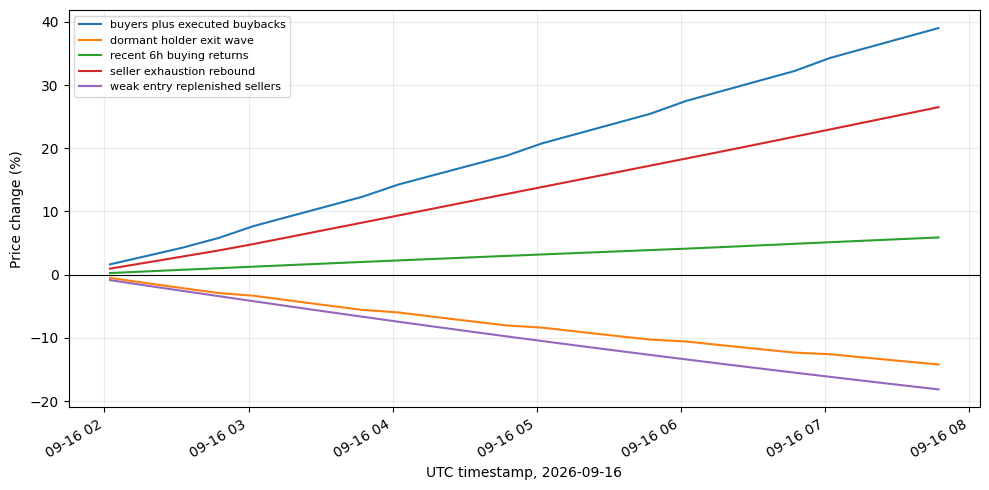

In [6]:
display(pd.read_csv(OUT/'six-hour-cases.csv'))
p=pd.read_csv(OUT/'six-hour-paths.csv')
fig,ax=plt.subplots(figsize=(10,5))
for name,g in p.groupby('case'):
    ax.plot(pd.to_datetime(g.timestamp_utc),g.price_return*100,label=name.replace('_',' '))
ax.axhline(0,color='black',lw=.8);ax.set(xlabel='UTC timestamp, 2026-09-16',ylabel='Price change (%)')
ax.legend(fontsize=8);ax.grid(alpha=.25);fig.autofmt_xdate();plt.tight_layout();plt.show()

## Edit a scenario
Change the gross ETH budget, existing wallet tokens sold, and target below. This is a conditional pool calculation, not an investment recommendation or a transaction quote. Independent pool copies prevent previous notebook cells from changing the starting state.

In [7]:
ordinary_buyer_ETH = 200.0
wallet_tokens_sold = 3_000_000.0
target_appreciation = 0.25
p = ConcentratedPool(profile)
sale_ETH, sell_tax_ETH, filled = p.sell(wallet_tokens_sold)
p.buy(ordinary_buyer_ETH)
print(f'Final price change: {p.price/pool.price-1:+.2%}')
print(f'Further ETH to reach target: {price_buy_cost(p,pool.price*(1+target_appreciation)):,.2f}')
print(f'Sale proceeds after modeled fees: {sale_ETH:,.2f} ETH')

Final price change: -5.02%
Further ETH to reach target: 531.74
Sale proceeds after modeled fees: 285.64 ETH


## Optional future bank withdrawals
Accrual remains internal until branches retire. The sequential fee calculation models the increasing crowd-exit fee. One- and two-day cases hold issuance fixed, allow accrual before retirement, and omit reinvestment. They are liability sensitivities, not scheduled unlocks.

In [8]:
display(pd.read_csv(OUT/'optional-bank-exits.csv'))
display(pd.read_csv(OUT/'issuance-absorption.csv'))

,elapsed_days,timestamp_utc,fraction_of_ledger_withdrawn,gross_ledger,net_tokens_minted,weighted_resolution_fee,net_ETH_to_sellers,price_return_without_buys
0,0,2026-09-16T01:47:19+00:00,0.10,1.378277e+05,1.344194e+05,0.024729,13.788668,-0.007146
1,0,2026-09-16T01:47:19+00:00,0.25,3.445691e+05,3.288954e+05,0.045488,33.564109,-0.017349
2,0,2026-09-16T01:47:19+00:00,0.50,6.891383e+05,6.085997e+05,0.116869,61.651467,-0.031747
3,0,2026-09-16T01:47:19+00:00,1.00,1.378277e+06,9.305762e+05,0.324826,93.474287,-0.048158
4,1,2026-09-17T01:47:19+00:00,0.10,2.078277e+05,2.016127e+05,0.029904,20.644394,-0.010689
5,1,2026-09-17T01:47:19+00:00,0.25,5.195691e+05,4.800844e+05,0.075995,48.797683,-0.025171
6,1,2026-09-17T01:47:19+00:00,0.50,1.039138e+06,7.950192e+05,0.234924,80.142855,-0.041240
7,1,2026-09-17T01:47:19+00:00,1.00,2.078277e+06,1.210373e+06,0.417607,120.688581,-0.062211
8,2,2026-09-18T01:47:19+00:00,0.10,2.778277e+05,2.675544e+05,0.036977,27.348637,-0.014148
9,2,2026-09-18T01:47:19+00:00,0.25,6.945691e+05,6.123588e+05,0.118362,62.026138,-0.031938


,fraction_daily_issuance_withdrawn,STANDARD_sellable_before_AMM,buyer_ETH_at_spot_to_absorb,note
0,0.25,171500.0,18.760692,Small-flow approximation; assumes quiet 2% res...
1,0.50,343000.0,37.521385,Small-flow approximation; assumes quiet 2% res...
2,1.00,686000.0,75.042770,Small-flow approximation; assumes quiet 2% res...


## 7. A conditional re-entry policy

1. **Do not buy merely because the vault has ETH.** Look for actual `BuybackExecuted` events and compare realized hourly buying with selling. The first tick is only about 6.6 ETH.
2. **Separate a bounce from a durable recovery.** A bounce needs buying to exceed the currently active sellers. A durable recovery needs enough ongoing new/returning capital to absorb replacement sellers and eventual branch withdrawals.
3. **Watch the auction after its initial burst.** Does positive flow survive once the 48 remaining licenses sell, or while rational owners wait for a cheaper price? Are payments funded by new buys or by old inventories?
4. **Watch seller replacement.** The constructive signal is declining new seller inventory while fresh buying persists—not merely 340 empty seller addresses.
5. **Require room beyond trading friction.** At unchanged taxes/LP fees, a very small round trip needs roughly 7.33% spot appreciation just to break even before gas, router fees and slippage. A hypothetical +5.9% pool bounce does not establish a profitable buy-and-sell trade.
6. **Treat epoch routing as a later catalyst.** Track cumulative epoch flow and actual settlement near September 18 01:00:30 UTC. Do not count the same hook ETH as both expansion assets and buybacks.

For an owner with a low-accrual branch, preserving future issuance can be rational; a large accrued ledger has much more capital at risk and a different harvest decision. From cash without a Charter, token speculation is the available direct exposure while ETH Charter issuance is disabled. Opening an expensive branch or depositing into another owner's Charter is not an automatic safer alternative.

The strongest defensible conclusion is **wait for changed flows before assuming a new sustained uptrend**. Neither “the top is certainly in” nor “buybacks guarantee recovery” follows from the evidence. The notebook gives editable buy/sell budgets so the conclusion can change when the observations change.

## Evidence, reproducibility and limits

- Fresh state, public RPC requests/results, all 8,392 measured address balances, initialized ticks, registry permissions, vault history and read-only execution probes: [`reentry-evidence/`](reentry-evidence/).
- Reconciled participant histories and wallet capital: [`reentry-results/`](reentry-results/). Total token supply and every collected wallet token balance reconcile exactly in integer units. Branch counts and total pending reconcile. Provenance is approximate pro-rata accounting, not proof of beneficial owner, motivation or cost basis.
- Executed notebook: [`reentry_analysis.ipynb`](reentry_analysis.ipynb). Model: [`reentry_model.py`](reentry_model.py). Prior snapshots remain unchanged.
- Official mechanism description: [STANDARD whitepaper](https://standardreserve.xyz/whitepaper). Its static page/frontend informed ABI discovery and documented routing; deployed-state reads and events support observations. POL execution and exact future fee-routing settlement were not counterfactually simulated.
- Locked liquidity is assumed safe from removal as requested. It can still lose ETH through sales. Models omit gas, MEV, unobserved venues/funding, parameter changes, and unknown future participant preferences. No guaranteed floor or treasury redemption right is assumed.
